Dataset Loaded Successfully

First 5 Records
                                               title  \
0   Donald Trump Sends Out Embarrassing New Yearâ...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obamaâs Na...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  

Last 5 Records
                                                   title  \
23476  McPain: John

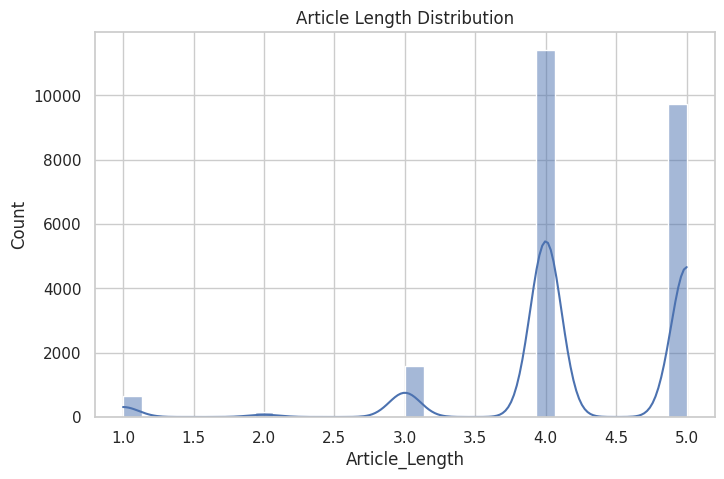

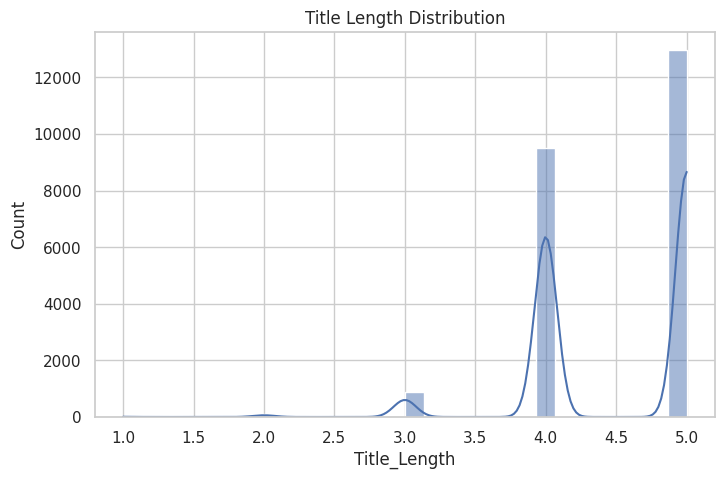

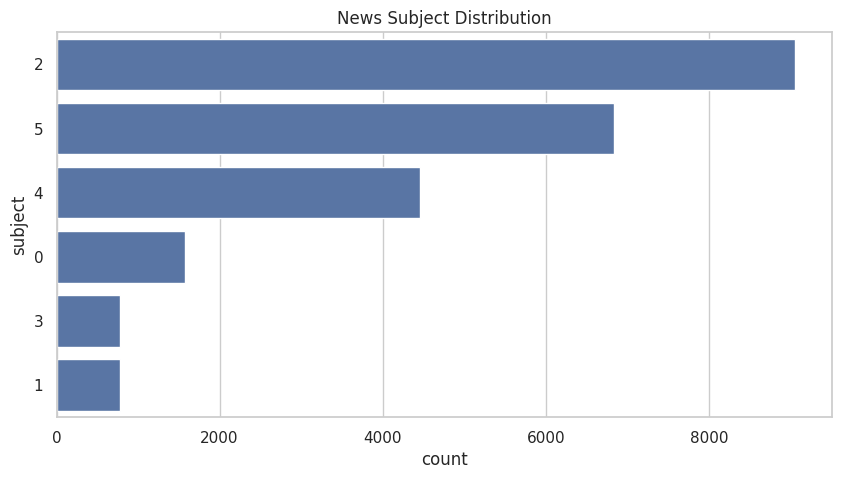


Cleaned Dataset Saved Successfully

EDA COMPLETED SUCCESSFULLY
Final Dataset Shape : (23478, 6)
Missing Values : 0
Duplicate Rows : 0
Numerical Columns : 0
Categorical Columns : 4


In [5]:
# ============================================================
# EXPERIMENT 3
# EXPLORATORY DATA ANALYSIS (EDA)
# FAKE NEWS DETECTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")

# ============================================================
# STEP 1 : LOAD DATASET
# ============================================================

df = pd.read_csv("/content/Fake.csv.zip", encoding="latin1")

print("Dataset Loaded Successfully")

# ============================================================
# STEP 2 : DISPLAY DATASET
# ============================================================

print("\nFirst 5 Records")
print(df.head())

print("\nLast 5 Records")
print(df.tail())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

# ============================================================
# STEP 3 : DATASET INFORMATION
# ============================================================

print("\nDataset Information")
print(df.info())

print("\nData Types")
print(df.dtypes)

# ============================================================
# STEP 4 : SUMMARY STATISTICS
# ============================================================

print("\nSummary Statistics")
print(df.describe(include='all'))

# ============================================================
# PROGRAM 1 : IDENTIFY MISSING VALUES
# ============================================================

print("\nMissing Values")
print(df.isnull())

# ============================================================
# PROGRAM 2 : COUNT MISSING VALUES
# ============================================================

print("\nCount Missing Values")
print(df.isnull().sum())

# ============================================================
# PROGRAM 3 : HANDLE MISSING VALUES
# ============================================================

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Filling")
print(df.isnull().sum())

# ============================================================
# PROGRAM 4 : REMOVE DUPLICATES
# ============================================================

print("\nDuplicate Records Before Removal")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nDuplicate Records After Removal")
print(df.duplicated().sum())

print("\nDataset Shape")
print(df.shape)

# ============================================================
# PROGRAM 5 : DETECT OUTLIERS
# ============================================================

print("\nOutlier Detection")

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "Outliers")

# ============================================================
# PROGRAM 6 : BOXPLOT
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title("Boxplot of " + col)

    plt.show()

# ============================================================
# PROGRAM 7 : HISTOGRAM
# ============================================================

if len(numeric_columns) > 0:

    df[numeric_columns].hist(figsize=(18,15))

    plt.tight_layout()

    plt.show()

# ============================================================
# PROGRAM 8 : CORRELATION HEATMAP
# ============================================================

if len(numeric_columns) > 1:

    plt.figure(figsize=(14,10))

    sns.heatmap(df[numeric_columns].corr(),
                annot=True,
                cmap="coolwarm")

    plt.title("Correlation Heatmap")

    plt.show()

# ============================================================
# PROGRAM 9 : NORMALIZATION
# ============================================================

if len(numeric_columns) > 0:

    scaler = MinMaxScaler()

    df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

    print("\nNormalized Data")

    print(df[numeric_columns].head())

# ============================================================
# PROGRAM 10 : LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:

    df[col] = label_encoder.fit_transform(df[col].astype(str))

print("\nLabel Encoding Completed")

print(df.head())

# ============================================================
# PROGRAM 11 : ONE HOT ENCODING
# ============================================================

one_hot = pd.get_dummies(df, columns=categorical_columns)

print("\nOne Hot Encoding Completed")

print(one_hot.head())

# ============================================================
# PROGRAM 12 : VALUE COUNTS
# ============================================================

print("\nUnique Values")

for col in categorical_columns:

    print("\nColumn :", col)

    print(df[col].value_counts().head())

# ============================================================
# PROGRAM 13 : DISTRIBUTION PLOTS
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col], kde=True)

    plt.title("Distribution of " + col)

    plt.show()

# ============================================================
# PROGRAM 14 : PAIR PLOT
# ============================================================

if len(numeric_columns) >= 2:

    sample = df[numeric_columns[:5]]

    sns.pairplot(sample)

    plt.show()

# ============================================================
# PROGRAM 15 : FAKE VS REAL NEWS
# ============================================================

if "label" in df.columns:

    plt.figure(figsize=(6,5))

    sns.countplot(x="label", data=df)

    plt.title("Fake vs Real News")

    plt.show()

    print("\nLabel Counts")

    print(df["label"].value_counts())

# ============================================================
# PROGRAM 16 : ARTICLE LENGTH ANALYSIS
# ============================================================

if "text" in df.columns:

    df["Article_Length"] = df["text"].astype(str).apply(len)

    plt.figure(figsize=(8,5))

    sns.histplot(df["Article_Length"], bins=30, kde=True)

    plt.title("Article Length Distribution")

    plt.show()

# ============================================================
# PROGRAM 17 : TITLE LENGTH ANALYSIS
# ============================================================

if "title" in df.columns:

    df["Title_Length"] = df["title"].astype(str).apply(len)

    plt.figure(figsize=(8,5))

    sns.histplot(df["Title_Length"], bins=30, kde=True)

    plt.title("Title Length Distribution")

    plt.show()

# ============================================================
# PROGRAM 18 : SUBJECT DISTRIBUTION
# ============================================================

if "subject" in df.columns:

    plt.figure(figsize=(10,5))

    sns.countplot(y=df["subject"],
                  order=df["subject"].value_counts().index)

    plt.title("News Subject Distribution")

    plt.show()

# ============================================================
# PROGRAM 19 : SAVE CLEANED DATASET
# ============================================================

df.to_csv("Cleaned_FakeNews_Dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully")

# ============================================================
# FINAL REPORT
# ============================================================

print("\n===================================")
print("EDA COMPLETED SUCCESSFULLY")
print("===================================")

print("Final Dataset Shape :", df.shape)

print("Missing Values :", df.isnull().sum().sum())

print("Duplicate Rows :", df.duplicated().sum())

print("Numerical Columns :", len(numeric_columns))

print("Categorical Columns :", len(categorical_columns))

print("===================================")